<a href="https://colab.research.google.com/github/jscrum/sellers/blob/main/examples/detr-part2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# https://huggingface.co/docs/transformers/main/en/model_doc/detr
# also look into MaskDINO

import io
import requests
from PIL import Image
import torch
import numpy

from transformers import AutoImageProcessor, DetrForSegmentation
from transformers.image_transforms import rgb_to_id

url = "https://d.newsweek.com/en/full/2442045/2024-hyundai-elantra.jpg?w=1200&f=10cce27f9fa3fd8afad08631a15b8aa2"
image = Image.open(requests.get(url, stream=True).raw)

image_processor = AutoImageProcessor.from_pretrained("facebook/detr-resnet-50-panoptic")
model = DetrForSegmentation.from_pretrained("facebook/detr-resnet-50-panoptic")

# prepare image for the model
inputs = image_processor(images=image, return_tensors="pt")

# forward pass
outputs = model(**inputs)

# Use the `post_process_panoptic_segmentation` method of the `image_processor` to retrieve post-processed panoptic segmentation maps
# Segmentation results are returned as a list of dictionaries
result = image_processor.post_process_panoptic_segmentation(outputs, target_sizes=[(300, 500)])

# A tensor of shape (height, width) where each value denotes a segment id, filled with -1 if no segment is found
panoptic_seg = result[0]["segmentation"]
# Get prediction score and segment_id to class_id mapping of each segment
panoptic_segments_info = result[0]["segments_info"]



/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/172M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:2397: UserWarning: for bn1.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pas

model.safetensors:   0%|          | 0.00/172M [00:00<?, ?B/s]

`label_ids_to_fuse` unset. No instance will be fused.


[{'id': 1, 'label_id': 192, 'was_fused': False, 'score': 0.911982}, {'id': 2, 'label_id': 187, 'was_fused': False, 'score': 0.999891}, {'id': 3, 'label_id': 192, 'was_fused': False, 'score': 0.612876}, {'id': 4, 'label_id': 149, 'was_fused': False, 'score': 0.994304}, {'id': 5, 'label_id': 125, 'was_fused': False, 'score': 0.87536}, {'id': 6, 'label_id': 3, 'was_fused': False, 'score': 0.999749}]


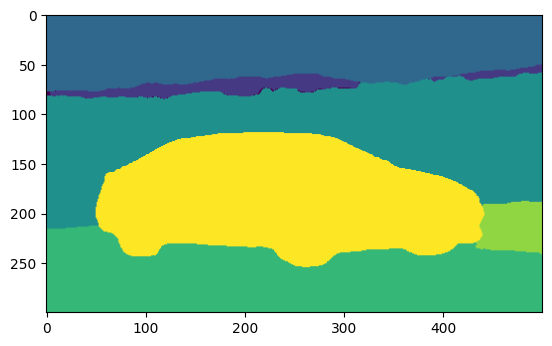

In [2]:
print(panoptic_segments_info)
import matplotlib.pyplot as plt
plt.imshow(panoptic_seg)
